In [ ]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read).
The token `sandrazhu` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `sandrazhu`


In [ ]:
pip install transformers datasets torch matplotlib

In [ ]:
from transformers import pipeline
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

In [ ]:
# Cargar datasets
dataset_emotion = load_dataset("cardiffnlp/super_tweeteval", "tweet_emotion", split="test")
dataset_topic = load_dataset("cardiffnlp/super_tweeteval", "tweet_topic", split="test")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

...

test.jsonl:   0%|          | 0.00/465k [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/161k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4585 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1679 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/573 [00:00<?, ? examples/s]

In [ ]:
# Cargar modelos y pipelines
topic_model = "cardiffnlp/twitter-roberta-base-topic-latest"
emotion_model = "cardiffnlp/twitter-roberta-base-emotion-latest"

topic_classifier = pipeline("text-classification", model=topic_model, tokenizer=topic_model, return_all_scores=False)
emotion_classifier = pipeline("text-classification", model=emotion_model, tokenizer=emotion_model, return_all_scores=False)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# Función para clasificar todos los tweets
def clasificar_tweets(dataset, classifier, columna="text", max_tweets=500):
    textos = []
    etiquetas = []
    for i in tqdm(range(min(len(dataset), max_tweets))):
        texto = dataset[i][columna]
        try:
            resultado = classifier(texto)
            etiqueta = resultado[0]['label']
        except:
            etiqueta = "error"
        textos.append(texto)
        etiquetas.append(etiqueta)
    return textos, etiquetas

# Clasificar y contar temas
print("Clasificando temas...")
tweets_topic, temas = clasificar_tweets(dataset_topic, topic_classifier)
conteo_temas = Counter(temas)

# Clasificar y contar emociones
print("Clasificando emociones...")
tweets_emotion, emociones= clasificar_tweets(dataset_emotion, emotion_classifier)
conteo_emociones = Counter(emociones)


Clasificando temas...


100%|██████████| 500/500 [02:39<00:00,  3.14it/s]


Clasificando emociones...


100%|██████████| 500/500 [01:40<00:00,  4.99it/s]


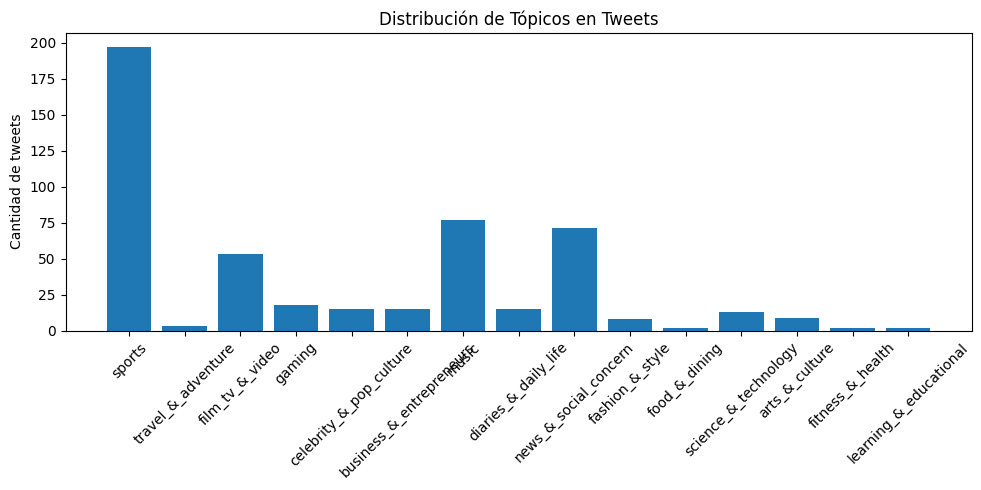

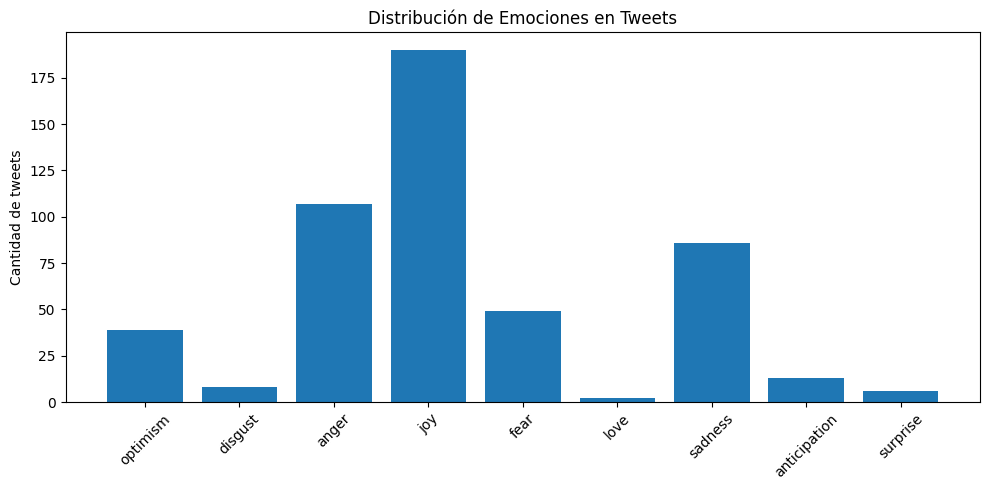

In [ ]:
# Función para graficar
def graficar_conteo(conteo, titulo):
    etiquetas = list(conteo.keys())
    valores = list(conteo.values())
    plt.figure(figsize=(10, 5))
    plt.bar(etiquetas, valores)
    plt.title(titulo)
    plt.ylabel("Cantidad de tweets")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Graficar resultados
graficar_conteo(conteo_temas, "Distribución de Tópicos en Tweets")
graficar_conteo(conteo_emociones, "Distribución de Emociones en Tweets")

In [ ]:
 pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
# Filtrar solo tweets de deporte
tweets_sports = [t for t, e in zip(tweets_topic, temas) if e.lower() == "sports"]

print(f"Total tweets: {len(tweets_topic)}")
print(f"Tweets de deporte: {len(tweets_sports)}")

# Topic modeling con BERTopic
if len(tweets_sports) > 0:
    topic_model = BERTopic(language="spanish", verbose=True)
    topics, probs = topic_model.fit_transform(tweets_sports)

    # Ver info de tópicos
    df_topics = topic_model.get_topic_info()
    print(df_topics)

    # Visualizar tópicos
    fig = topic_model.visualize_barchart(top_n_topics=10)
    fig.show()

    # Graficar frecuencia
    df_count = df_topics[df_topics.Topic != -1]  # quitar outliers
    plt.bar(df_count['Topic'], df_count['Count'])
    plt.xlabel("Tópico")
    plt.ylabel("Cantidad de tweets")
    plt.title("Frecuencia de subtemas en tweets deportivos")
    plt.show()
else:
    print("No se encontraron tweets de deporte en el conjunto analizado.")

NameError: name 'tweets_topic' is not defined